**Ejemplo simple de un problema QP usando ADMM**

alejandro.garces@utp.edu.co

$\min \frac{1}{2}x_A^\top Q_A x_A + \frac{1}{2}x_B^\top Q_B x_B + \frac{1}{2}x_C^\top Q_C x_C  $

$\sum x_A + \sum x_B + \sum x_C = 100$

In [1]:
using LinearAlgebra
using Plots
using JuMP
using Ipopt

In [2]:
A = 1:2
B = 3:5
C = 6:10
Q_A = [5 1; 1 3]
Q_B = [8 0 1; 0 9 0; 1 0 7]
Q_C = Diagonal([2;3;5;8;1])
nA = length(A)
nB = length(B)
nC = length(C)
nT = nA+nB+nC
f_A(x) = 1/2*x[A]'*Q_A*x[A]
f_B(x) = 1/2*x[B]'*Q_B*x[B]
f_C(x) = 1/2*x[C]'*Q_C*x[C]
Modelo = Model(Ipopt.Optimizer)
@variable(Modelo,x[1:nT])
@objective(Modelo,Min,f_A(x)+f_B(x)+f_C(x))
@constraint(Modelo,sum(x)==100)
optimize!(Modelo)


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:       10
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:       12

Total number of variables............................:       10
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        1
Total number of inequality c

In [3]:
xopt = value.(x)
round.(xopt,digits=3)

10-element Vector{Float64}:
  4.868
  9.737
  3.718
  3.787
  4.337
 17.039
 11.36
  6.816
  4.26
 34.079

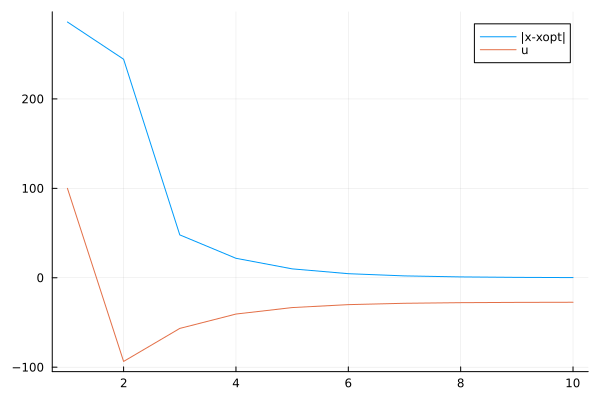

In [4]:
ρ = 0.8
argmin_fA(u,x) = -1/ρ*(sum(x[B])+sum(x[C])-100+u)*inv(Q_A+1/ρ*ones(nA,nA))*ones(nA)
argmin_fB(u,x) = -1/ρ*(sum(x[A])+sum(x[C])-100+u)*inv(Q_B+1/ρ*ones(nB,nB))*ones(nB)
argmin_fC(u,x) = -1/ρ*(sum(x[A])+sum(x[B])-100+u)*inv(Q_C+1/ρ*ones(nC,nC))*ones(nC)
np = 10
x=100*ones(nT,np)
u=100*ones(np)
for k = 2:np
    x[:,k] = x[:,k-1]
    x[A,k] = argmin_fA(u[k-1],x[:,k])
    x[B,k] = argmin_fB(u[k-1],x[:,k])
    x[C,k] = argmin_fC(u[k-1],x[:,k])
    u[k] = u[k-1] + (sum(x[:,k])-100)
end
err_x = [norm(x[:,k]-xopt) for k = 1:np]
p = plot(err_x, label="|x-xopt|")
p = plot!(u,label="u")
display(p)